In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Άσκηση - Ο μετασχηματισμός Z αριθμητικά

Πλέον γνωρίζετε καλά το μετασχηματισμό Z και τον αντίστροφο του (δηλ. τις τεχνικές με τις οποίες μπορούμε να τον αντιστρέψουμε, καθώς δε χρησιμοποιήσαμε τον ορισμό του αντιστρόφου μετασχ. Z μέσω του ολοκληρώματος). Ας δείξουμε σε αυτήν την άσκηση ότι μπορούμε να δουλέψουμε αριθμητικά με το μετασχ. Z και τον αντίστροφό του, με κάπως παρόμοιο τρόπο με το μετασχ. Fourier διακριτού χρόνου και τον αντίστροφό του.

Ξέρετε ότι

$$X(z) = X(re^{j\omega}) = \sum_{n=-\infty}^{+\infty}x[n]z^{-n} = \sum_{n=-\infty}^{+\infty}x[n]r^{-n}e^{-j\omega n}$$

Ας θεωρήσουμε το γνωστό ζεύγος

$$x[n] = 2^n u[n] \longleftrightarrow X(z) = \frac{1}{1-2z^{-1}}, \: \: |z| = r > 2$$

Ο μετασχηματισμός μπορεί να γραφεί ως

$$X(re^{j\omega}) = \frac{1}{1-2r^{-1}e^{-j\omega}} = \frac{1}{1-\frac{2}{r}e^{-j\omega}}, \: \: r > 2$$

Αυτό το σήμα δεν έχει μετασχηματισμό Fourier διακριτού χρόνου καθώς ο μοναδιαίος κύκλος $r = 1$ δεν περιλαμβάνεται στο πεδίο σύγκλισης $r > 2$. Όμως "μπορούμε να το κάνουμε να έχει" 😃!

Ας ορίσουμε το σήμα

$$\hat{x}[n] = 2^n u[n] r^{-n} = \left(\frac{2}{r}\right)^n u[n], \: \: r > 2$$

Αυτό το σήμα έχει μετασχ. Fourier διακριτού χρόνου

$$\hat{X}(e^{j\omega}) = \sum_{n=-\infty}^{+\infty}\hat{x}[n]e^{-j\omega n} = \sum_{n=-\infty}^{+\infty}\left(\frac{2}{r}\right)^n u[n]e^{-j\omega n} = \sum_{n=0}^{+\infty}\left(\frac{2}{r}e^{-j\omega}\right)^n = \frac{1}{1-\frac{2}{r}e^{-j\omega}}, \: \: r > 2$$

και αντίστροφο μετασχ. Fourier διακριτού χρόνου

$$\hat{x}[n] = \frac{1}{2\pi}\int_{-\pi}^{\pi}\hat{X}(e^{j\omega})e^{j\omega n}d\omega = \frac{1}{2\pi}\int_{-\pi}^{\pi}\frac{1}{1-\frac{2}{r}e^{-j\omega}}e^{j\omega n}d\omega, \: \: r > 2$$

Όμως εμάς μας νοιάζει το σήμα $x[n]$, όχι το $\hat{x}[n]$!

Μπορούμε να βρούμε το ζητούμενο σήμα πολλαπλασιάζοντας το $\hat{x}[n]$ με $r^{n}$, δηλ.

$$x[n] = \hat{x}[n]r^{n} = 2^n u[n] r^{-n} r^{n} = 2^n u[n]$$

και αντίστοιχα

$$x[n] = \hat{x}[n]r^{n} = r^{n}\frac{1}{2\pi}\int_{-\pi}^{\pi}\frac{1}{1-\frac{2}{r}e^{-j\omega}}e^{j\omega n}d\omega = \frac{1}{2\pi}\int_{-\pi}^{\pi}\frac{1}{1-\frac{2}{r}e^{-j\omega}}r^{n}e^{j\omega n}d\omega, \: \: r > 2$$

Παρατηρήστε ότι $r^{n}e^{j\omega n} = (re^{j\omega})^{n} = z^{n}$, οπότε η παραπάνω σχέση είναι ακριβώς ο αντίστροφος μετασχ. Z υπολογισμένος πάνω σε κύκλο ακτίνας $r$.

Ας χρησιμοποιήσουμε τα παραπάνω για να δούμε ότι πράγματι ο μετασχ. Z δουλεύει! Ας θέσουμε μια τιμή για την ακτίνα $r > 2$. Έστω $r = 3$. 

In [2]:
# Παράμετρος α
a = 2

# Άξονας διακριτού χρόνου [-2,5] (δείγματα)
n = np.arange(-2, 6)

# Βήμα στη συχνότητα
dw = 2 * np.pi / 600
# Άξονας συχνότητας (-π,π]
w = np.arange(-np.pi, np.pi + dw, dw)

# Σήμα (0 για n < 0, a^n για n >= 0)
x = np.where(n < 0, 0, a ** n.astype(float))

# Επιλογή μιας τιμής της ακτίνας r (έστω 3, όπως αναφέραμε)
r = 3

Τώρα μπορούμε να χρησιμοποιήσουμε το μετασχ. Z στην "ανοιχτή" μορφή του (με $z=re^{j\omega}$) και να ανακατασκευάσουμε το σήμα στο χρόνο σύμφωνα με την τελευταία σχέση για το σήμα $x[n]$ που καταλήξαμε παραπάνω!

In [3]:
# Μετασχηματισμός Z για r = 3 (δειγματοληψία πάνω σε κύκλο ακτίνας r)
X = 1.0 / (1 - a * (r * np.exp(1j * w)) ** (-1))

# Δέσμευση μνήμης
x_est = np.zeros_like(n, dtype=complex)

# Σύνθεση του x[n] από μια "φέτα" του μετασχ. Z για r=3
for i in range(len(w)):
    x_est += X[i] * (r ** n.astype(float)) * np.exp(1j * w[i] * n)

# Κανονικοποίηση με Δω/2π λόγω του αθροίσματος Riemann του αντίστροφου μετασχ.
x_est = (dw / (2 * np.pi)) * x_est

Ας απεικονίσουμε το αρχικό $x[n]$ και το ανακατασκευασμένο σήμα ``x_est``!

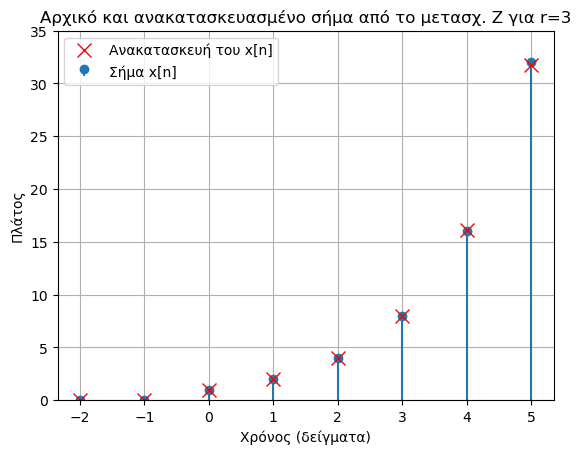

In [ ]:
# Γράφημα
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='Σήμα x[n]')
plt.plot(n, x_est.real, 'rx', markersize=10, label='Ανακατασκευή του x[n]')
plt.grid()
plt.legend()
plt.ylim([0, 35])                                                          # Zoom στο κομμάτι [0,35] του y'y
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Z για r=3')    # Ομορφαίνουμε
plt.xlabel('Χρόνος (δείγματα)')                                            # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                       # Ομορφαίνουμε
plt.show()

Βλέπετε ότι παρ' όλο που το σήμα "φεύγει" στο άπειρο όταν $n \to +\infty$, εμείς μπορέσαμε να το ανακατασκευάσουμε, απλά χρειαστήκαμε μιγαδικά εκθετικά με αύξον (αντί σταθερό) πλάτος - δηλ. δειγματοληπτήσαμε το μετασχ. Z πάνω σε κύκλο ακτίνας $r=3$ και όχι στον μοναδιαίο κύκλο!

---

Γράψτε κώδικα ``Python`` για να αντιστρέψετε μέσω του μετασχ. Z για κάποια κατάλληλη ακτίνα $r$ της επιλογής σας το σήμα $x[n]$ για τα παρακάτω ζεύγη:

(α') $$x[n] = -\left(\frac{1}{3}\right)^n u[-n-1] \longleftrightarrow X(z) = \frac{1}{1-\frac{1}{3}z^{-1}}, \: \: |z| = r < \frac{1}{3}$$
(β') $$x[n] = \left(\frac{1}{2}\right)^n u[n] - 2^n u[-n-1] \longleftrightarrow X(z) = \frac{1}{1-\frac{1}{2}z^{-1}} + \frac{1}{1-2z^{-1}}, \: \: \frac{1}{2} < |z| = r < 2$$

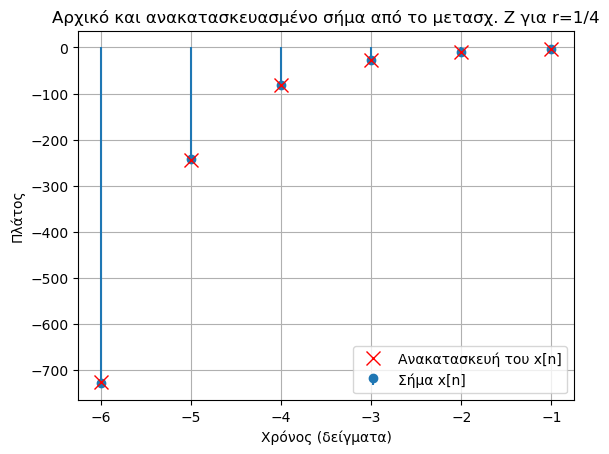

In [5]:
# (α')
# INSERT CODE HERE

# Παράμετρος α
a = 1/3

# Άξονας διακριτού χρόνου [-6,-1] (δείγματα)
n = np.arange(-6, 0)

# Βήμα στη συχνότητα
dw = 2 * np.pi / 600
# Άξονας συχνότητας (-π,π]
w = np.arange(-np.pi, np.pi + dw, dw)

# Σήμα (0 για n >= 0, -a^n για n <= -1)
x = np.where(n >= 0, 0, -a ** n.astype(float))

# Επιλογή μιας τιμής της ακτίνας r (r < 1/3)
r = 1/4

# Μετασχηματισμός Z για r = 1/4
X = 1.0 / (1 - a * (r * np.exp(1j * w)) ** (-1))

# Δέσμευση μνήμης
x_est = np.zeros_like(n, dtype=complex)

# Σύνθεση του x[n] από μια "φέτα" του μετασχ. Z
for i in range(len(w)):
    x_est += X[i] * (r ** n.astype(float)) * np.exp(1j * w[i] * n)

# Κανονικοποίηση με Δω/2π λόγω του αθροίσματος Riemann του αντίστροφου μετασχ.
x_est = (dw / (2 * np.pi)) * x_est

# Γράφημα
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='Σήμα x[n]')
plt.plot(n, x_est.real, 'rx', markersize=10, label='Ανακατασκευή του x[n]')
plt.grid()
plt.legend()
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Z για r=1/4')    # Ομορφαίνουμε
plt.xlabel('Χρόνος (δείγματα)')                                            # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                       # Ομορφαίνουμε
plt.show()

# END OF CODE

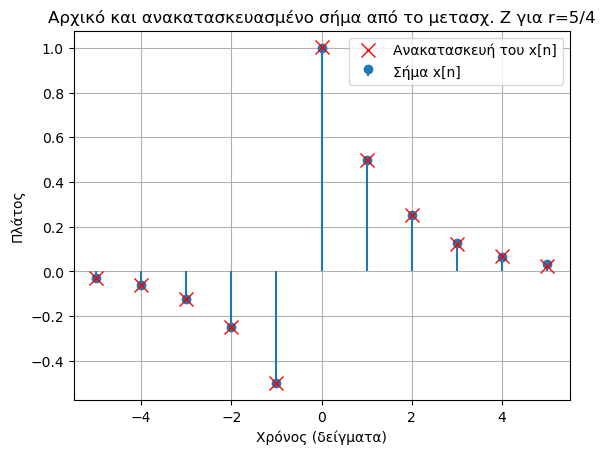

In [6]:
# (β')
# INSERT CODE HERE

# Παράμετροι α, β
a = 1/2
b = 2

# Άξονας διακριτού χρόνου [-5,5] (δείγματα)
n = np.arange(-5, 6)

# Βήμα στη συχνότητα
dw = 2 * np.pi / 600
# Άξονας συχνότητας (-π,π]
w = np.arange(-np.pi, np.pi + dw, dw)

# Σήμα (a^n για n >= 0, -b^n για n <= -1)
x = np.where(n >= 0, a ** n.astype(float), -b ** n.astype(float))

# Επιλογή μιας τιμής της ακτίνας r (1/2 < r < 2)
r = 5/4

# Μετασχηματισμός Z για r = 5/4
X = 1.0 / (1 - a * (r * np.exp(1j * w)) ** (-1)) + 1.0 / (1 - b * (r * np.exp(1j * w)) ** (-1))

# Δέσμευση μνήμης
x_est = np.zeros_like(n, dtype=complex)

# Σύνθεση του x[n] από μια "φέτα" του μετασχ. Z
for i in range(len(w)):
    x_est += X[i] * (r ** n.astype(float)) * np.exp(1j * w[i] * n)

# Κανονικοποίηση με Δω/2π λόγω του αθροίσματος Riemann του αντίστροφου μετασχ.
x_est = (dw / (2 * np.pi)) * x_est

# Γράφημα
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='Σήμα x[n]')
plt.plot(n, x_est.real, 'rx', markersize=10, label='Ανακατασκευή του x[n]')
plt.grid()
plt.legend()
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Z για r=5/4')    # Ομορφαίνουμε
plt.xlabel('Χρόνος (δείγματα)')                                            # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                       # Ομορφαίνουμε
plt.show()

# END OF CODE

---
---